In [4]:

# Clip tidal models to Cape Cod bounding box
import os
from eo_tides.utils import clip_models
from eo_tides.utils import list_models

available_models, supported_models = list_models(
    directory="tide_models/"
)
# Define bounding Box
bbox_capecod = [-70.451122, 41.172320, -69.578025, 42.198560]
print(os.getcwd())
clip_models(input_directory = "tide_models/",
            output_directory = "tide_models_clipped",
            model = "FES2022_extrapolated",
            bbox = bbox_capecod)

─────────────────────────────────────────────────────────────────────────────
 󠀠🌊  | Model                | Expected path                                  
─────────────────────────────────────────────────────────────────────────────
 ❌  │ AODTM-5              │ tide_models\aodtm5_tmd                         
 ❌  │ AOTIM-5              │ tide_models\aotim5_tmd                         
 ❌  │ AOTIM-5-2018         │ tide_models\Arc5km2018                         
 ❌  │ Arc2kmTM             │ tide_models\Arc2kmTM                           
 ❌  │ CATS0201             │ tide_models\cats0201_tmd                       
 ❌  │ CATS2008             │ tide_models\CATS2008                           
 ❌  │ CATS2008-v2023       │ tide_models\CATS2008_v2023                     
 ❌  │ CATS2008_load        │ tide_models\CATS2008a_SPOTL_Load               
 ✅  │ DTU23                │ tide_models\DTU23_OceanTide\DTU23              
 ✅  │ EOT20                │ tide_models\EOT20\ocean_tides               

Clipping FES2022_extrapolated: 100%|██████████| 34/34 [00:00<00:00, 17843.64it/s]


 ✅ Clipped model exported and verified

Outputs exported to tide_models_clipped
────────────────────────────────────────────────────────────────────────────────
 󠀠🌊  | Model                | Expected path                                          
────────────────────────────────────────────────────────────────────────────────
 ✅  │ EOT20                │ tide_models_clipped\EOT20\ocean_tides                  
 ✅  │ FES2022_extrapolated │ tide_models_clipped\fes2022b\ocean_tide_extrapolated   
 ✅  │ GOT5.5               │ tide_models_clipped\GOT5.5\ocean_tides                 
 ✅  │ GOT5.6               │ tide_models_clipped\GOT5.6\ocean_tides                 
────────────────────────────────────────────────────────────────────────────────

Summary:
Available models: 4/55


In [24]:
# Get tide height data for Marconi Beach
import pandas as pd
from eo_tides.model import model_phases

tide_df= model_phases(
        x=-69.963189,
        y=41.896050, 
        time=pd.date_range("2025-01-23", "2025-02-19", freq="15min"),
        model=["EOT20", "GOT5.5","GOT5.6","FES2022_extrapolated"],
        output_format = "wide",
        directory="tide_models_clipped/",
        return_tides = True,
)

tide_df["time"] = pd.date_range("2025-01-23", "2025-02-19", freq="15min")

Modelling tides with EOT20, GOT5.5, GOT5.6, FES2022_extrapolated in parallel (models: 4, splits: 1)


100%|██████████| 4/4 [00:03<00:00,  1.24it/s]


Modelling tides with EOT20, GOT5.5, GOT5.6, FES2022_extrapolated in parallel (models: 4, splits: 1)


100%|██████████| 4/4 [00:03<00:00,  1.26it/s]


Converting to a wide format dataframe


In [26]:
# Print dataframe with added tide height data:
tide_df.head()

tide_df.to_csv("tidal_data_marconi_modelled.csv", index=False)

In [91]:
import pandas as pd
df = pd.read_csv("tidal_data_marconi_modelled.csv",skiprows=1)
df = df.rename(columns={'Unnamed: 8': 'time'})
df['time'] = pd.to_datetime(df['time'])
print(df)
print(list(df.columns))

         EOT20  FES2022_extrapolated    GOT5.5    GOT5.6   EOT20.1  \
0     0.393310              0.449896  0.439974  0.451253  high-ebb   
1     0.348313              0.399504  0.385117  0.396271  high-ebb   
2     0.295884              0.342036  0.322915  0.333775  high-ebb   
3     0.236926              0.278422  0.254434  0.264842  high-ebb   
4     0.172476              0.209667  0.180854  0.190658  high-ebb   
...        ...                   ...       ...       ...       ...   
2588  0.106790              0.093408  0.093820  0.102788  high-ebb   
2589  0.011566             -0.003570 -0.006168  0.001983  high-ebb   
2590 -0.084710             -0.100520 -0.106188 -0.098965   low-ebb   
2591 -0.180320             -0.195786 -0.204507 -0.198309   low-ebb   
2592 -0.273544             -0.287724 -0.299422 -0.294331   low-ebb   

     FES2022_extrapolated.1  GOT5.5.1  GOT5.6.1                time  
0                  high-ebb  high-ebb  high-ebb 2025-01-23 00:00:00  
1                  


['EOT20', 'FES2022_extrapolated', 'GOT5.5', 'GOT5.6', 'EOT20.1', 'FES2022_extrapolated.1', 'GOT5.5.1', 'GOT5.6.1', 'time']


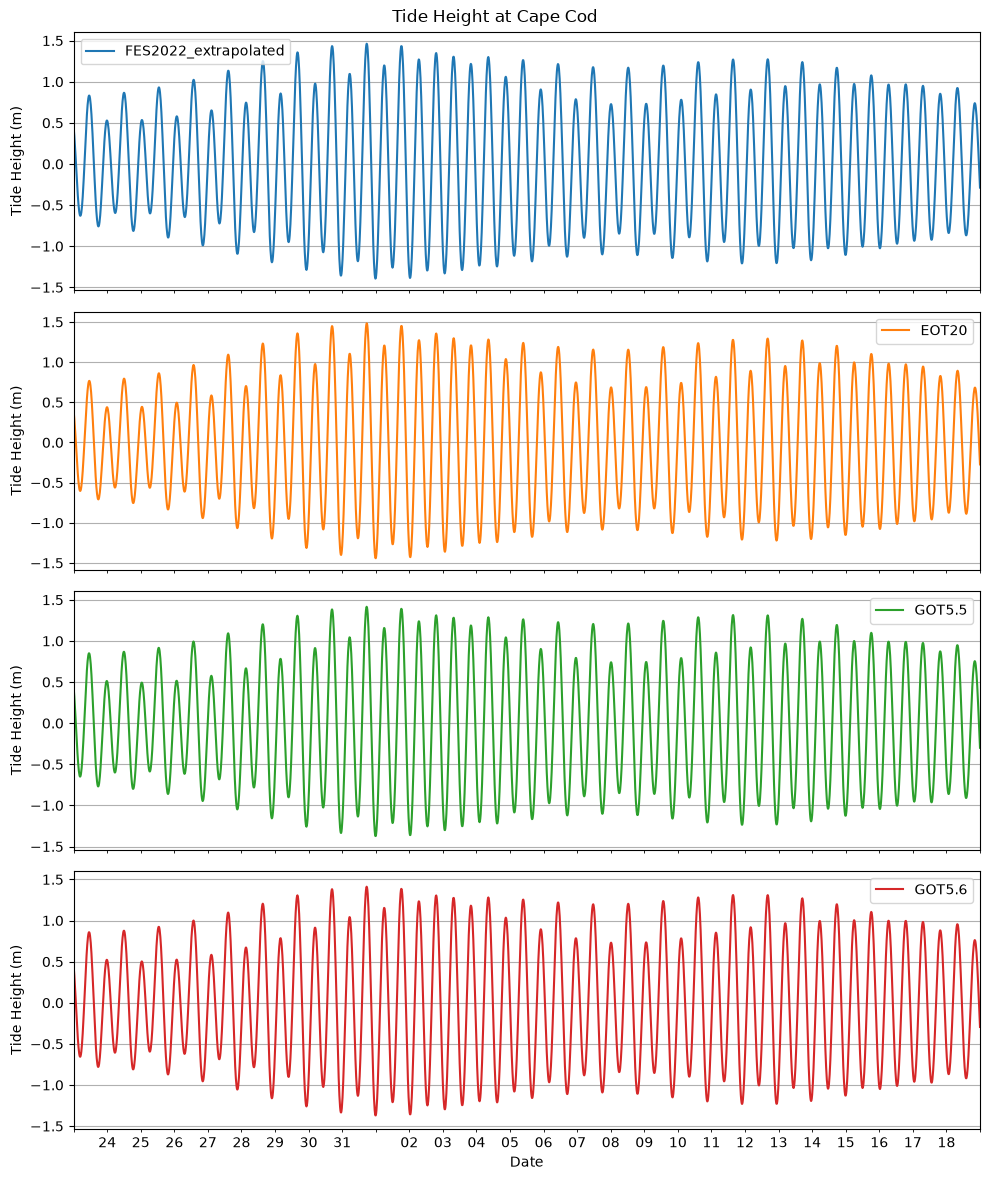

In [94]:
# Print outputs
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tide_columns= ["FES2022_extrapolated","EOT20","GOT5.5","GOT5.6"]


axes = df.plot(figsize = (10, 12),
                    x = "time",
                    y = tide_columns,
                    legend=True,
                    title="Tide Height at Cape Cod",
                    ylabel="Tide Height (m)",
                    xlabel="Date",
                    subplots=True,
                    grid=True,);

for ax in axes:
    ax.plot(df["time"], 
            df["FES2022_extrapolated"],
            color = "black",
            linewidth=10,
            alpha = 0.3,
            zorder = 3,
           )
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
